# 00 - Raw duty sweep characterization

## Purpose

This notebook is the first in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. The
series starts from raw ADC readings and derives every quantity in the open.
Later notebooks compare these derivations against what the firmware
computes on the servo.

This notebook has three jobs:

1. Document the measurement chain and the constants that convert ADC
   readings into volts and amperes (section 2).
2. Measure the offset, noise, and limits of each raw channel (section 5).
3. Check that the data follows the expected brushed DC motor behavior
   (section 6).

The dataset is two test series with identical method, one powered from a
5 V USB source and one from a 2-cell lithium battery. The two series were
not captured on the same measurement chain. The USB series is on the
current chain (I call it chain 3 below). The battery series is on the
previous chain (chain 2) and is retired until I recapture it on chain 3.
It stays in this notebook as a comparison only, and every place it shows
up is labeled, so a difference between the two series can be the supply,
the session, or the chain.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain, as
built for the USB series (chain 3):

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned. The controller commands **duty**. Duty is the fraction of each
  PWM period during which the bridge applies the supply across the motor.
  Duty is signed. Negative duty drives the opposite direction. For the
  rest of the period the bridge shorts the winding through its low-side
  switches (slow decay), the mode used throughout this dataset.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. The pot wiper connects
  directly to an ADC pin, so position readings convert to volts at the
  wiper with no divider. Converting wiper volts to output angle requires an
  angle calibration, which a later notebook derives, so position stays in
  wiper volts here.
- A 60 mOhm shunt resistor in the motor return path, amplified with gain
  15.0, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included.
- Both motor terminals are read through 6.8 kOhm / 3.3 kOhm resistor
  dividers, channels `vmotor_a` and `vmotor_b`. The bottom leg of each
  divider returns to a bias node $V_B$ of about 0.63 V (nominally 0.628 V
  from a 200 Ohm / 47 Ohm divider off VDD), so a terminal that swings
  below ground keeps its ADC pin above ground and stays readable. Each
  tap has a 150 pF reservoir capacitor, which is what lets the ADC's
  sample capacitor charge quickly from a divider of a few kOhm. Section 2
  gives the tap formula and section 5.3 measures the bias.
- Each 50 us control period the ADC, clocked at 48 MHz, scans seven
  channels, triggered at the crest of the PWM counter, in the order shunt,
  `vmotor_a`, `vmotor_b`, position, a calibration reference, supply
  sense, and an NTC thermistor. The shunt uses a shorter sample aperture
  than the other channels. A second shunt sample at the trough of the
  counter gives `current_trough`.
- The controller streams every sample at the control rate (20,000 per
  second), packed 16 samples to a frame with a CRC. Corrupted frames are
  dropped and counted, so corruption turns into missing samples (verified
  in section 4). The wire budget at this rate allows six fields per
  sample. These recordings selected the six raw fields (position, both
  shunt samples, applied duty, both terminals). Supply sense and the NTC
  are streamable as `vbus_raw` and `ntc_raw` but were left out, so those
  two columns are empty and play no part in the analysis.

The battery series was captured on chain 2, which had a 33 mOhm shunt,
20 kOhm / 10 kOhm terminal dividers, a 430 Ohm / 100 Ohm bias divider
(nominally 0.623 V), no reservoir capacitors, and a slower ADC clock. The
amplifier gain and the shunt sampling floor are the same on both chains.
Section 2 has both chains side by side.

**The board is a hacked rig.** The board under both series is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). I know of one defect on it that the next board revision
does not have. The bus telemetry stream couples into the current
amplifier's output, so a shunt sample taken while a frame is going out on
the wire can read a few counts off. On the scan geometry of this firmware
build it does not show at rest (section 5.2 checks this by binning the
rest current by the sample's position inside the 16-sample frame), but
it is a known limitation of this board, and I do not code around it
anywhere in this notebook.

Power for the two test series, captured in separate sessions:

- **USB series.** A laptop USB port. The voltage reaching the motor is
  measured in section 6.2. It is well below the nominal 5 V and drops
  further under load.
- **Battery series.** A 2-cell lithium battery, nominal 7.4 V, measured
  in section 6.2. The pack was not recharged before the session. This supply
  is above the 4.8 to 6 V range usually quoted for SG90-class servos, so
  the full-duty steps in the battery series stress the mechanism beyond
  its usual rating.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
per chain. The shunt, the divider legs, the amplifier gain, and VDD are
written into every recording's `meta.json` by the capture tool (the
`sense` block), and the loader in section 3 checks each recording against
this table and stops with an error if they disagree. The bias divider,
the reservoir capacitor, and the sampling floors are not in the metadata,
so this table is the only record of them.

| Quantity | Chain 3 (USB series) | Chain 2 (battery series, retired) |
|---|---|---|
| ADC resolution | 12 bit (0..4095 counts) | same |
| ADC reference | VDD, nominal 3.300 V | same |
| ADC clock | 48 MHz | slower, not recorded here |
| Motor terminal divider | 6.8 kOhm top / 3.3 kOhm bottom, bottom leg returned to the terminal bias | 20 kOhm / 10 kOhm, same return |
| Terminal tap reservoir | 150 pF per tap | none |
| Terminal bias $V_B$, nominal | 200 Ohm / 47 Ohm from VDD, 0.628 V | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording and per terminal, from the segment-0 baseline (section 5.3) | same |
| Current shunt | 60 mOhm | 33 mOhm |
| Current amplifier gain | 15.0 | 15.0 |
| Control period | 50 us (20 kHz) | same |
| PWM counter | 1200 timer ticks per half period, center aligned | same |
| Duty encoding | signed, 32767 = 100% | same |
| Current sampling floor | 160 timer ticks = 13.3% duty | 160 ticks = 13.3% |
| Voltage sampling floor | 120 timer ticks = 10.0% duty | 210 ticks = 17.5% |

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

The divider ratio $r$ is 3.06 on chain 3 and exactly 3 on chain 2. With
the bridge off and no current, both taps read $V_B$ exactly, which is how
the bias is measured per recording (section 5.3). Every absolute terminal
voltage below uses the second form with the measured $V_B$ of its own
terminal in its own recording. The difference of the two terminals is
bias-free when both dividers share the one bias node, so that
$v_A - v_B = r\,(\text{tap}_A - \text{tap}_B)$ in ADC volts.

Two caveats:

- The ADC reference is the chip's VDD supply. The 3.300 V figure is the
  design value, and the actual VDD of this unit was not measured. Every
  voltage below scales linearly with the true VDD, so one future
  measurement of VDD rescales everything by one factor.
- The divider ratio, shunt, and gain are design values. Component
  tolerances were not measured, and absolute voltages and currents carry
  them. The bias itself is measured, so it adds no tolerance of its own.

The derived conversion factors, per chain:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- constants shared by both chains ---
ADC_COUNTS = 4096           # 12-bit converter
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire

# --- per-chain constants (the table above) ---
# shunt/divider/gain/vdd are cross-checked against meta.json `sense`;
# bias divider and floors exist only here.
CHAIN_TABLE = {
    3: dict(label="chain 3", shunt_mohm=60, div_top=6_800, div_bot=3_300,
            gain_milli=15_000, vdd_mv=3_300, bias_top=200, bias_bot=47,
            floor_i_ticks=160, floor_v_ticks=120),
    2: dict(label="chain 2, retired", shunt_mohm=33, div_top=20_000, div_bot=10_000,
            gain_milli=15_000, vdd_mv=3_300, bias_top=430, bias_bot=100,
            floor_i_ticks=160, floor_v_ticks=210),
}
# which chain each campaign folder was captured on
CAMPAIGN_CHAIN = {"usb": 3, "2s": 2}

class Chain:
    # Conversion factors for one measurement chain.
    def __init__(self, n):
        c = CHAIN_TABLE[n]
        self.n, self.label = n, c["label"]
        self.vdd_v = c["vdd_mv"] / 1e3
        self.v_adc_per_count = self.vdd_v / ADC_COUNTS                  # volts at the ADC pin
        self.div_ratio = (c["div_top"] + c["div_bot"]) / c["div_bot"]  # r in the tap formula
        self.v_term_per_count = self.v_adc_per_count * self.div_ratio  # terminal volts per tap count
        self.vb_nom_v = self.vdd_v * c["bias_bot"] / (c["bias_top"] + c["bias_bot"])
        self.shunt_ohm = c["shunt_mohm"] / 1e3
        self.amp_gain = c["gain_milli"] / 1e3
        self.a_per_count = self.v_adc_per_count / (self.amp_gain * self.shunt_ohm)
        self.floor_i_pct = c["floor_i_ticks"] * 100.0 / PWM_HALF_TICKS
        self.floor_v_pct = c["floor_v_ticks"] * 100.0 / PWM_HALF_TICKS
        self.sense = {"shunt_r_mohm": c["shunt_mohm"], "vmotor_div_top": c["div_top"],
                      "vmotor_div_bot": c["div_bot"], "gain_milli": c["gain_milli"],
                      "vdd_mv": c["vdd_mv"]}

    def check_meta(self, meta, where):
        # Fail loudly if a recording was captured on different parts than
        # this table says. The keys are the capture tool's `sense` block.
        got = {k: meta["sense"][k] for k in self.sense}
        if got != self.sense:
            raise ValueError(f"{where}: meta.json sense {got} != {self.label} table {self.sense}")

    def term_V(self, tap_counts, vb_counts):
        # Absolute terminal voltage from a tap reading: Vt = r tap - (r-1) VB.
        return (self.div_ratio * tap_counts - (self.div_ratio - 1) * vb_counts) * self.v_adc_per_count

CHAINS = {n: Chain(n) for n in CHAIN_TABLE}

rows = []
for ch in CHAINS.values():
    rows += [
        {"chain": ch.label, "quantity": "pot wiper", "value": ch.v_adc_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal divider ratio r", "value": ch.div_ratio, "unit": ""},
        {"chain": ch.label, "quantity": "motor terminal difference", "value": ch.v_term_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal bias, nominal", "value": ch.vb_nom_v * 1e3, "unit": "mV"},
        {"chain": ch.label, "quantity": "terminal bias, nominal", "value": ch.vb_nom_v / ch.v_adc_per_count, "unit": "counts"},
        {"chain": ch.label, "quantity": "motor current", "value": ch.a_per_count * 1e3, "unit": "mA per count"},
        {"chain": ch.label, "quantity": "current sampling floor", "value": ch.floor_i_pct, "unit": "% duty"},
        {"chain": ch.label, "quantity": "voltage sampling floor", "value": ch.floor_v_pct, "unit": "% duty"},
    ]
pd.DataFrame(rows).set_index(["quantity", "unit", "chain"])["value"].unstack("chain").round(4)


chain                                   chain 2, retired   chain 3
quantity                  unit                                    
current sampling floor    % duty                 13.3333   13.3333
motor current             mA per count            1.6276    0.8952
motor terminal difference mV per count            2.4170    2.4658
pot wiper                 mV per count            0.8057    0.8057
terminal bias, nominal    counts                772.8302  779.4008
                          mV                    622.6415  627.9352
terminal divider ratio r                          3.0000    3.0606
voltage sampling floor    % duty                 17.5000   10.0000

## 3. Capture method

The recordings live in the repository under `notebooks/telemetry/sg90/`,
ten per supply, in the `usb` and `2s` folders. One recording contains 41
segments, captured back to back:

- **Segment 0** is a one-second baseline with the motor undriven. It
  measures the noise floor of each channel, the current amplifier's
  offset, and the terminal bias.
- **Segments 1 to 40** are constant-duty drive steps, duty from 5% to 100%
  in 5% increments, first forward then reverse. Each step drives for 80 ms
  with full-rate capture, followed by 500 ms of rest. Before each step the
  servo is repositioned at 15% duty toward the far end of travel, so there
  is room to accelerate.

Between recordings the servo was rebooted and rested for one minute, so
every recording starts from the same software state and similar thermal
state. Both series follow this method exactly. The differences are the
supply, the session, and the measurement chain.

**Braking between steps.** After each step's capture window closes, the
sweep tool commands a 0.25% duty with slow-decay switching, which
short-circuits the motor winding for 99.75% of every PWM period and brakes
the motor to rest. The braking happens after the capture window, so the
recorded data is unaffected.

**Data acceptance.** Any recording in which the host counted even one
dropped frame was discarded and re-run. Section 4 re-verifies this from
the data itself.

Each row of a recording is one 50 us sample, holding the segment
number, commanded duty, direction, tick counter, the firmware's
sampling-validity flag (section 5.4), the raw channels (position, crest
and trough shunt samples, applied duty, both motor terminals), and the
two empty columns for supply sense and the NTC. The loader attaches to
every recording its baseline constants, the current offset (mean of
`current_raw` over segment 0) and the terminal bias $V_B$ of each terminal
(median of `vmotor_a` and of `vmotor_b` over segment 0). It also checks
the recording's `sense` block against the chain table of section 2.


In [2]:
TELEMETRY = Path("telemetry/sg90")

def load_recording(rec_dir, chain):
    # One recording = sweep.csv.gz (per-tick samples) + meta.json (settings).
    # Derived columns: duty_pct (signed percent), t_ms (ms since start),
    # and the per-recording baseline constants bias, vb (terminal A), vb_b.
    df = pd.read_csv(rec_dir / "sweep.csv.gz")
    meta = json.loads((rec_dir / "meta.json").read_text())
    chain.check_meta(meta, rec_dir)
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["t_ms"] = (df["tick"] - df["tick"].iloc[0]) / (TICK_HZ / 1000)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    return df, meta

def load_series(campaign):
    chain = CHAINS[CAMPAIGN_CHAIN[campaign]]
    base = TELEMETRY / campaign
    recs = {}
    for d in sorted(base.glob("capture-*"), key=lambda p: int(p.name.split("-")[1])):
        recs[d.name] = load_recording(d, chain)
    return recs

usb = load_series("usb")
batt = load_series("2s")

# Every loop below walks this list: (label, recordings, chain).
SERIES = [("usb", usb, CHAINS[CAMPAIGN_CHAIN["usb"]]),
          ("2s battery", batt, CHAINS[CAMPAIGN_CHAIN["2s"]])]
pd.DataFrame({"recordings": [len(recs) for _, recs, _ in SERIES],
              "chain": [ch.label for _, _, ch in SERIES]},
             index=[label for label, _, _ in SERIES])


,recordings,chain
usb,10,chain 3
2s battery,10,"chain 2, retired"


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. One frame
carries 16 consecutive samples, so a dropped frame appears as a 16-tick
jump in the tick column. The table below recomputes the missing-sample
count for every recording from the tick column.


In [3]:
def integrity(recs):
    rows = []
    for name, (df, meta) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
    return pd.DataFrame(rows)

pd.concat([integrity(recs).assign(series=label) for label, recs, _ in SERIES],
          ignore_index=True)


,recording,samples,segments,missing_samples,series
0,capture-1,84000,41,0,usb
1,capture-2,84000,41,0,usb
2,capture-3,84000,41,0,usb
3,capture-4,84000,41,0,usb
4,capture-5,84000,41,0,usb
5,capture-6,84000,41,0,usb
6,capture-7,84000,41,0,usb
7,capture-8,84000,41,0,usb
8,capture-9,84000,41,0,usb
9,capture-10,84000,41,0,usb


Every recording holds 84,000 samples in 41 segments with zero missing
samples.

## 5. Channel characterization

### 5.1 Position

The position channel is the pot wiper voltage. The baseline segment of
each recording gives its noise floor at rest. The repositioning move
before the baseline ends with the motor unpowered, and at battery voltage
the mechanism can still be coasting to rest when the capture starts. The
code below measures this residual motion two ways, as the offset of the
first 100 ms from the settled level and as the time of the last sample
outside the settled noise band. The noise statistics drop the first 200 ms
of the one-second baseline and use the settled remainder. The pot wiper
goes straight to an ADC pin on both chains, but the ADC clock changed
between them, so the noise floor is a per-chain number too.


In [4]:
rows = []
for series, recs, ch in SERIES:
    for name, (df, _) in recs.items():
        base = df[df["seg"] == 0]["pos"].to_numpy() * ch.v_adc_per_count
        settled = base[len(base) // 5:]
        med = np.median(settled)
        band = np.max(np.abs(settled - med))
        outside = np.where(np.abs(base - med) > band)[0]
        rows.append({
            "series": series,
            "peak_dev_mV": band * 1e3,
            "std_mV": np.std(settled) * 1e3,
            # residual coast from the repositioning move: how far the
            # first 100 ms sits from the settled level, and when the
            # trace last leaves the settled band
            "coast_first_100ms_mV": abs(np.median(base[:2000]) - med) * 1e3,
            "coast_settle_ms": (outside[-1] + 1) / (TICK_HZ / 1000) if len(outside) else 0.0,
        })
pd.DataFrame(rows).groupby("series").agg(["mean", "max"]).round(2)


peak_dev_mV       std_mV       coast_first_100ms_mV        \
                  mean   max   mean   max                 mean   max   
series                                                                 
2s battery        6.53  8.86   1.60  1.76                 6.69  9.67   
usb               4.27  7.25   1.04  1.98                 0.24  1.61   

           coast_settle_ms          
                      mean     max  
series                              
2s battery          103.12  168.35  
usb                   7.27   41.10

On the USB series (chain 3) the rest noise has a standard deviation of
about 1 mV and a peak deviation under 7.3 mV at the wiper (one ADC count
is 0.81 mV). On the battery series (chain 2) it is about 1.6 mV and under
9 mV. The battery coast lasts up to 168 ms, inside the 200 ms trimmed from
every baseline. On USB the mechanism is at rest within 41 ms. Section 6.1
uses the peak deviation as the bound for deciding whether a drive step
produced real motion.

### 5.2 Current offset

The bridge is disabled during the baseline, so no current flows through
the shunt and the baseline reading is the amplifier's output offset. It is
measured below from every baseline segment of both series, with the rest
noise of the channel next to it. The mA-equivalent column uses each
chain's own shunt, so it is not comparable across the two series. The
second table is the board caveat from section 1. It bins the USB series'
rest current by the sample's position inside the 16-sample telemetry
frame. If the bus stream were reaching the shunt samples at rest, some
positions would read higher than others.


In [5]:
rows = []
for label, recs, ch in SERIES:
    offs = np.array([df["bias"].iloc[0] for df, _ in recs.values()])
    # rest noise: std of the settled baseline (first 200 ms dropped), per recording
    noise = np.array([df[df["seg"] == 0]["current_raw"].to_numpy()[4000:].std()
                      for df, _ in recs.values()])
    off_v = offs.mean() * ch.v_adc_per_count
    rows.append({
        "series": label,
        "offset_counts": offs.mean(),
        "offset_counts_min": offs.min(),
        "offset_counts_max": offs.max(),
        "offset_mV": off_v * 1e3,
        "offset_mA_equivalent": off_v / (ch.amp_gain * ch.shunt_ohm) * 1e3,
        "recording_spread_mV": offs.std() * ch.v_adc_per_count * 1e3,
        "rest_noise_std_counts": noise.mean(),
        "rest_noise_std_mA": noise.mean() * ch.a_per_count * 1e3,
    })
display(pd.DataFrame(rows).set_index("series").round(2))

# Board caveat check: rest current by position inside the 16-sample frame,
# pooled over the ten USB recordings. Position = tick mod 16.
phase = pd.concat([df[df["seg"] == 0].assign(frame_pos=lambda d: d["tick"] % 16)
                   for df, _ in usb.values()])
by_pos = phase.groupby("frame_pos")[["current_raw", "current_trough"]].mean()
by_pos.loc["spread (max - min)"] = by_pos.max() - by_pos.min()
by_pos.round(2).T


,offset_counts,offset_counts_min,offset_counts_max,offset_mV,offset_mA_equivalent,recording_spread_mV,rest_noise_std_counts,rest_noise_std_mA
series,,,,,,,,
usb,111.55,110.02,112.96,89.87,99.85,0.69,1.97,1.76
2s battery,102.89,102.07,103.85,82.90,167.47,0.40,1.74,2.84


frame_pos,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,spread (max - min)
current_raw,110.61,111.49,111.53,111.66,111.82,111.68,111.80,111.71,111.74,111.56,111.70,111.67,111.80,111.64,111.18,111.16,1.22
current_trough,110.89,111.44,110.33,110.35,110.41,109.87,110.46,110.38,110.38,109.73,110.33,110.44,110.43,109.81,110.90,110.28,1.71


Within a series the offset is stable to under a millivolt across ten
reboot-separated recordings. The USB session reads 110 to 113 counts and
the battery session 102 to 104 counts, so the two chains and sessions
differ by about 9 counts (7 mV). The offset is large on both. On chain 3
it is worth about 100 mA equivalent through the 60 mOhm shunt, on chain 2
about 170 mA through the 33 mOhm one, so it must be subtracted before
current readings mean anything. Later notebooks subtract the
per-recording baseline value. The rest noise is about 2 counts standard
deviation on both chains, which the larger shunt turns into 1.8 mA on
chain 3 against 2.8 mA on chain 2. *Hypothesis (not tested here): the
session difference tracks the board's supply or temperature. Testing it
requires baselines on both supplies within one session.*

The frame-position table is flat. Across the sixteen positions the crest
sample spans 1.2 counts and the trough sample 1.7 counts, against a
per-sample noise of 2 counts. Each bin pools 12,500 samples, so the
spread is real, but it is about 1 mA and well under the noise, which is
what I meant by invisible at rest. It stays on the list as a board
limitation.

### 5.3 Terminal bias

With the bridge off and no current in the winding, both terminal dividers
sit at the bias node, so the baseline reads $V_B$ directly on both
channels. The median over the full one-second baseline is robust against
the coasting motor's back-EMF in the first tens of milliseconds. The table
compares the two channels and the nominal value per series.


In [6]:
rows = []
for label, recs, ch in SERIES:
    vb = np.array([df["vb"].iloc[0] for df, _ in recs.values()])
    vb_b = np.array([df["vb_b"].iloc[0] for df, _ in recs.values()])
    rows.append({
        "series": label,
        "VB_A_counts_min": vb.min(),
        "VB_A_counts_max": vb.max(),
        "VB_A_mV": vb.mean() * ch.v_adc_per_count * 1e3,
        "VB_B_counts_min": vb_b.min(),
        "VB_B_counts_max": vb_b.max(),
        "VB_B_mV": vb_b.mean() * ch.v_adc_per_count * 1e3,
        "B_minus_A_counts_min": (vb_b - vb).min(),
        "B_minus_A_counts_max": (vb_b - vb).max(),
        "VB_nominal_mV": ch.vb_nom_v * 1e3,
        "VB_A_minus_nominal_mV": (vb.mean() * ch.v_adc_per_count - ch.vb_nom_v) * 1e3,
        "VB_B_minus_nominal_mV": (vb_b.mean() * ch.v_adc_per_count - ch.vb_nom_v) * 1e3,
    })
pd.DataFrame(rows).set_index("series").round(2).T


series,usb,2s battery
VB_A_counts_min,766.00,776.00
VB_A_counts_max,766.00,777.00
VB_A_mV,617.14,625.92
VB_B_counts_min,784.00,778.00
VB_B_counts_max,784.00,779.00
VB_B_mV,631.64,627.37
B_minus_A_counts_min,18.00,1.00
B_minus_A_counts_max,18.00,2.00
VB_nominal_mV,627.94,622.64
VB_A_minus_nominal_mV,-10.80,3.28


On chain 2 (battery series) both taps read the bias within 1 to 2 counts
of each other, 776 to 779 counts, 3 to 5 mV above the 0.623 V nominal.
On chain 3 (USB series) the two taps do not agree. `vmotor_a` reads 766
counts (0.617 V, 11 mV below the 0.628 V nominal) and `vmotor_b` reads
784 counts (0.632 V, 4 mV above), an 18-count split that is exactly the
same on all ten recordings. With the bridge off, the winding ties the two
terminals together and both dividers return to the one bias node, so the
two taps should read the same. They do not, and I have not chased why.
It could be a real potential difference from bridge leakage through the
new lower-resistance dividers, or it could be the ADC, since `vmotor_a`
is scanned right after the shunt channel and `vmotor_b` right after
`vmotor_a`. Either way it is stable, so every absolute terminal voltage
below uses the terminal's own rest reading as its $V_B$, which absorbs
the split as an offset. A 1-count uncertainty in $V_B$ enters an absolute
terminal voltage multiplied by $r - 1$, about 2 mV, and is left
uncorrected.

### 5.4 Sampling floors and the validity flag

The scan is triggered at the crest of the PWM counter, which under slow
decay is the center of the drive window. The crest sample therefore sits
inside the drive window at every nonzero duty. Whether it is settled
depends on how far the window's edge is from the scan. The firmware
states two floors, 160 of the 1200 half-period ticks for current (13.3%
duty) on both chains, and a voltage floor of 120 ticks (10.0%) on chain 3
against 210 (17.5%) on chain 2. It stamps every sample with a validity
flag that encodes the current floor. The voltage floor is set where both
terminal dividers have settled, and it came down on chain 3 because the
lower divider resistance and the reservoir capacitor settle much faster.
The figure below shows the driven terminal's raw samples at three duty
levels on a chain 3 recording, then the table checks where the recorded
flag flips.


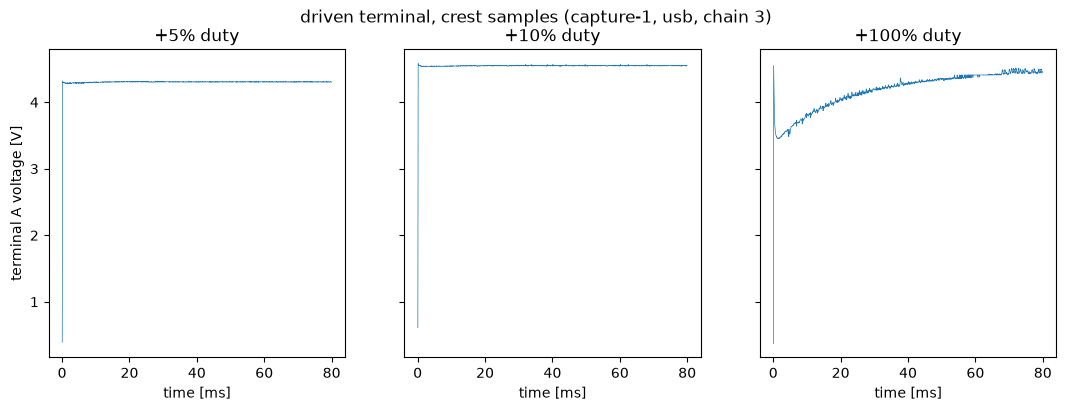

,recordings,distinct_flip_points,invalid_up_to_pct,valid_from_pct
series,,,,
usb,10,1,10.0,15.0
2s battery,10,1,10.0,15.0


In [7]:
name, (df, meta) = next(iter(usb.items()))
ch = CHAINS[CAMPAIGN_CHAIN["usb"]]
vb = df["vb"].iloc[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, pct in zip(axes, [5, 10, 100]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (TICK_HZ / 1000)
    ax.plot(t, ch.term_V(seg["vmotor_a"], vb), lw=0.5)
    ax.set_title(f"+{pct}% duty")
    ax.set_xlabel("time [ms]")
axes[0].set_ylabel("terminal A voltage [V]")
fig.suptitle(f"driven terminal, crest samples ({name}, usb, {ch.label})")
plt.show()

# Where does the recorded validity flag flip? Checked in every recording
# of both series.
rows = []
for label, recs, ch in SERIES:
    flips = set()
    for df, _ in recs.values():
        v = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid_frac=("window_valid", "mean"))
        v["mag"] = v["d"].abs().round()
        flips.add((v[v.valid_frac <= 0.5]["mag"].max(),
                   v[v.valid_frac > 0.5]["mag"].min()))
    rows.append({
        "series": label,
        "recordings": len(recs),
        "distinct_flip_points": len(flips),
        "invalid_up_to_pct": max(h for h, _ in flips),
        "valid_from_pct": min(l for _, l in flips),
    })
pd.DataFrame(rows).set_index("series")


At +100% duty the crest sample reads near the supply voltage in every
period, after a dip in the first few milliseconds while the USB rail sags
under the inrush and recovers. At +10% it reads the supply from the first
period. At +5% it still reads about 4.3 V, a quarter volt low, because the
drive window's edge is 60 ticks from the scan and the divider has not
quite settled. On chain 2 the same +5% step read about -0.1 V, so the
reservoir capacitor and the lower divider resistance make a big
difference here. The motor receives its share of the supply during that
step either way, and the position data in section 6.1 shows the servo
moving at 10%.

The recorded flag flips between the 10% and 15% duty steps in every
recording of both series, consistent with the 160-tick current floor on
this 5% grid. The two terminals settle at different points. The table
below pools the driven terminal's median reading per step across all
recordings, terminal A for forward steps and terminal B for reverse, each
bias-corrected with its own rest reading.


In [8]:
rows = []
for label, recs, ch in SERIES:
    for df, _ in recs.values():
        vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        for seg_id, seg in df.groupby("seg"):
            d = seg["duty_pct"].iloc[0]
            mag = int(round(abs(d)))
            if seg_id == 0 or mag > 25:
                continue
            term, vb = (seg["vmotor_a"], vb_a) if d > 0 else (seg["vmotor_b"], vb_b)
            rows.append({
                "series": label,
                "terminal": "A (forward)" if d > 0 else "B (reverse)",
                "duty_mag_pct": mag,
                "driven_V": ch.term_V(term.median(), vb),
            })
(pd.DataFrame(rows)
   .groupby(["duty_mag_pct", "series", "terminal"])["driven_V"].mean()
   .unstack(["series", "terminal"]).round(2))


series        2s battery                     usb            
terminal     A (forward) B (reverse) A (forward) B (reverse)
duty_mag_pct                                                
5                  -0.10        0.00        4.35        4.51
10                  7.38        0.00        4.60        4.56
15                  7.36        7.37        4.60        4.55
20                  7.35        7.35        4.58        4.54
25                  7.35        7.34        4.57        4.53

On chain 3 both terminals read the supply from the 10% step, and they are
within a quarter volt of it even at 5%. On chain 2, terminal A read the
supply from the 10% step, but terminal B read near zero at 10% and the
supply only from 15%, so its edge lay between 10% and 15% duty. That is
why the chain 2 voltage floor was 17.5% and the chain 3 floor is 10%.
This imposes two rules on everything below:

- Current readings and terminal voltage readings are used only where the
  validity flag is set, which on this grid means the 15% step and up. On
  chain 2 the terminal voltage is additionally restricted to duty at or
  above the 17.5% floor, so the 20% step and up. On chain 3 the 10%
  voltage floor sits below the flag, so the flag is the only gate.
- Below those floors the position channel is the only trusted channel.
  The pot wiper is sampled directly, outside the PWM window, so position
  has no such limit.

## 6. Results

### 6.1 Motion threshold

For each drive step, net travel is the difference between the median of
the last 20 and the first 20 position samples (medians so a single noise
spike cannot fake motion). This is compared against the rest-noise band
from section 5.1. One complication needs handling. Each drive step begins
shortly after a repositioning move, and the mechanism can still be
coasting from that move when the step begins (section 5.1 measures this in
the baselines). Drive-produced motion follows the commanded direction.
Residual coast follows the repositioning move, which by construction of
the test runs opposite the drive direction. So besides the per-step
scatter, the table pools travel aligned with the drive direction across
all recordings. Position does not go through the parts that changed
between chains, so this section compares the two supplies directly.


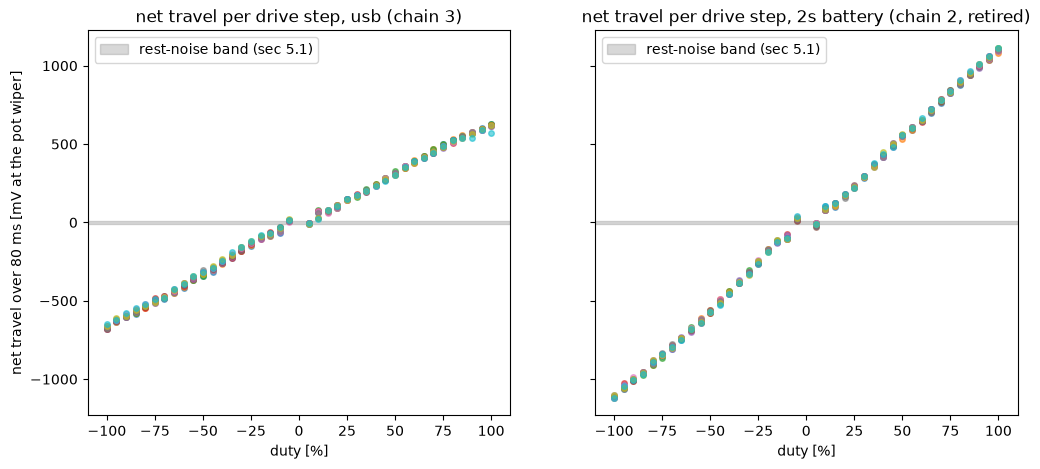

usb                    2s battery                   
               mean   std    min count       mean   std    min count
duty_mag_pct                                                        
5.0            -9.2   4.7  -22.6    20      -17.5  10.1  -38.3    20
10.0           49.5  20.1   20.9    20       92.1  12.8   74.9    20
15.0           73.3   7.6   58.8    20      119.1   8.2   99.1    20
20.0           98.3   9.4   81.4    20      177.0   7.8  157.5    20
25.0          139.7  11.3  118.4    20      241.7  15.8  218.7    20

In [9]:
def step_travel(df, ch):
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        p = seg["pos"].to_numpy() * ch.v_adc_per_count * 1e3   # mV at the wiper
        out.append({
            "duty_pct": seg["duty_pct"].iloc[0],
            "travel_mV": np.median(p[-20:]) - np.median(p[:20]),
        })
    return pd.DataFrame(out)

def rest_band_mV(df, ch):
    base = df[df["seg"] == 0]["pos"].to_numpy() * ch.v_adc_per_count * 1e3
    settled = base[len(base) // 5:]
    return np.max(np.abs(settled - np.median(settled)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bands = {}
for ax, (title, recs, ch) in zip(axes, SERIES):
    band = 0.0
    for name, (df, meta) in recs.items():
        tr = step_travel(df, ch)
        band = max(band, rest_band_mV(df, ch))
        ax.plot(tr["duty_pct"], tr["travel_mV"], "o", ms=4, alpha=0.6)
    bands[title] = band
    ax.axhspan(-band, band, color="grey", alpha=0.3,
               label="rest-noise band (sec 5.1)")
    ax.set_xlabel("duty [%]")
    ax.set_title(f"net travel per drive step, {title} ({ch.label})")
    ax.legend(loc="upper left")
axes[0].set_ylabel("net travel over 80 ms [mV at the pot wiper]")
plt.show()

# Drive-aligned travel by |duty| in mV; positive = moved in the
# commanded direction.
tables = {}
for label, recs, ch in SERIES:
    allt = pd.concat([step_travel(df, ch) for df, _ in recs.values()])
    allt["aligned_mV"] = allt["travel_mV"] * np.sign(allt["duty_pct"])
    tables[label] = (allt.assign(duty_mag_pct=np.abs(allt["duty_pct"]).round())
                         .groupby("duty_mag_pct")["aligned_mV"]
                         .agg(["mean", "std", "min", "count"]).head(5))
aligned = pd.concat(tables, axis=1)
aligned.round(1)


Findings:

- At 10% duty the servo moves on both supplies. The mean aligned travel is
  roughly +50 mV per 80 ms step on USB and +92 mV on battery, in the
  commanded direction. On battery the smallest of the twenty steps clears
  the rest-noise band by an order of magnitude. On USB the smallest step
  (21 mV) clears the 7 mV band by about three times, with a wide spread
  between steps.
- At 5% duty the aligned travel is slightly negative with a tight spread on
  both supplies. Drive cannot produce motion opposite the command. Residual
  coast can, and its direction opposes the drive direction here by
  construction. The 5% steps are therefore consistent with zero
  drive-produced motion.

So the motion threshold of this unit lies between 5% and 10% duty on both
supplies. Section 6.2 converts this duty bracket into a voltage bracket
once the supply is measured.

### 6.2 Supply voltage under load

These recordings carry no supply-sense samples (section 1). They have the
two motor terminals. While the bridge drives, the driven terminal connects
to the supply through the high-side switch, so its voltage is the supply
minus the switch drop. The estimate below takes, per drive step, the 90th
percentile of the driven terminal's valid samples (terminal A when driving
forward, terminal B in reverse), bias-corrected with that terminal's own
$V_B$ from the recording and restricted to duty at or above the chain's
voltage floor (10% on chain 3, 17.5% on chain 2). Steps below the floor
have no valid voltage samples and are absent from the figure. The table
also reports the partner terminal at full duty, which the low-side switch
holds near ground, as a check on the bias correction. The battery curve
is on the retired chain, so its absolute level carries that chain's
divider tolerance, not this one's.


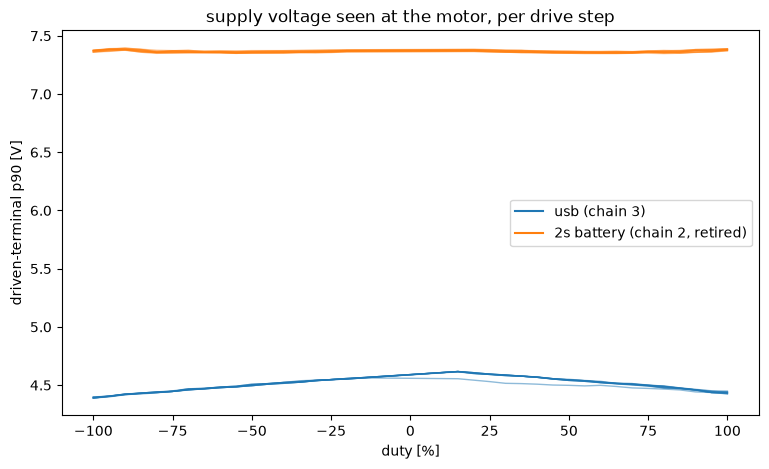

,light_load_V,full_duty_V,drop_mV,low_side_full_duty_V
series,,,,
usb,4.57,4.41,158.34,0.13
2s battery,7.37,7.37,-6.01,0.12


In [10]:
def step_supply(df, ch):
    # Supply estimate per drive step: p90 of the driven terminal, valid
    # samples at or above the voltage floor only. low_side_V is the
    # median of the partner terminal over the same samples. Each terminal
    # is bias-corrected with its own rest reading.
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        d = seg["duty_pct"].iloc[0]
        if abs(d) < ch.floor_v_pct:
            continue
        v = seg[seg["window_valid"] == 1]
        if len(v) < 100:
            continue
        if d > 0:
            hi, lo, vbh, vbl = v["vmotor_a"], v["vmotor_b"], vb_a, vb_b
        else:
            hi, lo, vbh, vbl = v["vmotor_b"], v["vmotor_a"], vb_b, vb_a
        out.append({"duty_pct": d,
                    "supply_V": ch.term_V(hi.quantile(0.9), vbh),
                    "low_side_V": ch.term_V(lo.median(), vbl)})
    return pd.DataFrame(out).sort_values("duty_pct")

COLORS = {"usb": "tab:blue", "2s battery": "tab:orange"}

fig, ax = plt.subplots(figsize=(9, 5))
for label, recs, ch in SERIES:
    for name, (df, _) in recs.items():
        r = step_supply(df, ch)
        ax.plot(r["duty_pct"], r["supply_V"], "-", lw=1, alpha=0.5, color=COLORS[label])
    ax.plot([], [], "-", color=COLORS[label], label=f"{label} ({ch.label})")
ax.set_xlabel("duty [%]")
ax.set_ylabel("driven-terminal p90 [V]")
ax.set_title("supply voltage seen at the motor, per drive step")
ax.legend()
plt.show()

rows = []
for label, recs, ch in SERIES:
    hi, lo, ls = [], [], []
    for df, _ in recs.values():
        r = step_supply(df, ch)
        full = r[r["duty_pct"].abs() >= 95]
        lo.append(full["supply_V"].mean())
        ls.append(full["low_side_V"].mean())
        hi.append(r[r["duty_pct"].abs() <= 30]["supply_V"].mean())
    rows.append({
        "series": label,
        "light_load_V": np.mean(hi),
        "full_duty_V": np.mean(lo),
        "drop_mV": (np.mean(hi) - np.mean(lo)) * 1e3,
        "low_side_full_duty_V": np.mean(ls),
    })
supply = pd.DataFrame(rows).set_index("series")
supply.round(2)


Findings:

- The USB series delivers about 4.57 V at light load, already well below
  the nominal 5 V, and drops by roughly another 0.16 V as duty rises to
  100%. The curve peaks around 15% and falls off to both sides, and the
  first few milliseconds of every high-duty step dip much lower than the
  p90 shows (the +100% panel of section 5.4). *Hypothesis (not tested
  here): the standing deficit and the load dependence are resistive and
  diode drops in the cable, connectors, and the board's input path.
  Testing it requires measuring the voltage at the port and at the board
  input at the same time.*
- The battery series delivers about 7.4 V, flat within 10 mV across the
  duty range on this p90 measure. This is the retired chain's number.
- The low-side terminal reads 0.12 to 0.13 V at full duty after the bias
  correction, the drop across the conducting low-side switch. Without the
  correction it would read $(r - 1) V_B$ higher.

Every fit below that divides by supply voltage therefore uses the per-step
measured value.

**The motion threshold as a voltage.** If the threshold of section 6.1 is
a fixed voltage (the voltage needed to overcome friction), the relevant
axis is duty times the supply voltage. The table applies the light-load
supply of each series to its 5% and 10% steps and marks which of them
moved (aligned travel beyond the rest-noise band).


In [11]:
rows = []
for label, _, _ in SERIES:
    for pct in [5, 10]:
        rows.append({
            "series": label,
            "duty_pct": pct,
            "applied_V": pct / 100.0 * supply.loc[label, "light_load_V"],
            "aligned_travel_mV": aligned.loc[pct, (label, "mean")],
            "moved": bool(aligned.loc[pct, (label, "mean")] > bands[label]),
        })
pd.DataFrame(rows).set_index(["series", "duty_pct"]).round(2)


applied_V  aligned_travel_mV  moved
series     duty_pct                                     
usb        5              0.23              -9.18  False
           10             0.46              49.53   True
2s battery 5              0.37             -17.52  False
           10             0.74              92.15   True

The highest step that did not move is the battery 5% step at 0.37 V.
The lowest step that moved is the USB 10% step at 0.46 V. The minimum
voltage that produces motion therefore lies between 0.37 and 0.46 V for
this unit. A single supply brackets this a factor of two wide. The second
supply squeezes the bracket to under 25%, with the caveat that the two
ends of the bracket come from two chains. Why a DC motor needs a minimum
voltage to start moving is a friction question, taken up in notebook 04.

### 6.3 Speed vs effective voltage

For each drive step above the motion threshold, the steady speed is the
slope of a least-squares line through the last 60% of the step's position
trace, past the initial acceleration. For a brushed DC motor at steady
speed, the average applied voltage is duty times the supply voltage, and
speed rises linearly with it. This section tests whether the raw data
follows that model across two supplies nearly 3 V apart. Keep in mind
that the voltage axis of each series comes from its own chain, so a slope
mismatch between them can be divider tolerance as much as physics. The
speed axis is position-derived and does not have that problem.

Steps below the chain's voltage floor have no same-step supply
measurement. Those steps use the mean supply of the gentlest measurable
steps of the same recording (up to 30% duty). Section 6.2 shows the
supply varies little at low duty, so the substitution costs a few tens of
millivolts at most. The fit table also repeats the fit with one supply
value per series (the mean over all measurable steps) to show what the
per-step correction is worth.


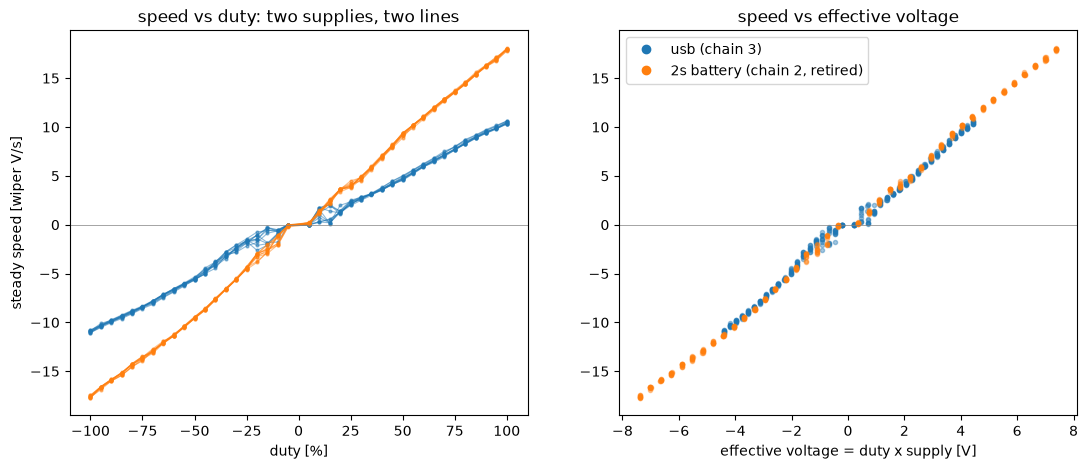

,usb slope_Vps_per_V,usb intercept_Vps,2s battery slope_Vps_per_V,2s battery intercept_Vps,slope_difference_pct
per-step supply,2.369,-0.232,2.452,-0.082,3.424
single supply per series,2.349,-0.201,2.453,-0.083,4.317


In [12]:
def step_speeds(df, ch):
    sup = step_supply(df, ch).set_index("duty_pct")["supply_V"]
    sup_lo = sup[np.abs(sup.index) <= 30].mean()
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        n = len(seg)
        tail = seg.iloc[int(n * 0.4):]
        t = (tail["tick"] - tail["tick"].iloc[0]) / TICK_HZ
        slope = np.polyfit(t, tail["pos"] * ch.v_adc_per_count, 1)[0]
        d = seg["duty_pct"].iloc[0]
        out.append({
            "duty_pct": d,
            "speed_Vps": slope,                       # wiper volts per second
            "supply_V": sup.get(d, sup_lo),
            "supply_mean_V": sup.mean(),
        })
    return pd.DataFrame(out)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, recs, ch in SERIES:
    for name, (df, meta) in recs.items():
        sp = step_speeds(df, ch).sort_values("duty_pct")
        axes[0].plot(sp["duty_pct"], sp["speed_Vps"], "-o", ms=2, lw=0.8,
                     alpha=0.5, color=COLORS[label])
        veff = sp["duty_pct"] / 100.0 * sp["supply_V"]
        axes[1].plot(veff, sp["speed_Vps"], "o", ms=3, alpha=0.4, color=COLORS[label])
    axes[1].plot([], [], "o", color=COLORS[label], label=f"{label} ({ch.label})")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("steady speed [wiper V/s]")
axes[0].set_title("speed vs duty: two supplies, two lines")
axes[1].set_xlabel("effective voltage = duty x supply [V]")
axes[1].set_title("speed vs effective voltage")
axes[1].legend()
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
plt.show()

fits = {}
for label, recs, ch in SERIES:
    pts = pd.concat([step_speeds(df, ch) for df, _ in recs.values()])
    for kind, col in [("per-step supply", "supply_V"),
                      ("single supply per series", "supply_mean_V")]:
        veff = pts["duty_pct"] / 100.0 * pts[col]
        m = veff.abs() > 1.0     # fit above 1 V, clear of the motion threshold
        k = np.polyfit(veff[m], pts["speed_Vps"][m], 1)
        fits.setdefault(kind, {})[f"{label} slope_Vps_per_V"] = k[0]
        fits[kind][f"{label} intercept_Vps"] = k[1]
fits = pd.DataFrame(fits).T
fits["slope_difference_pct"] = (
    (fits["2s battery slope_Vps_per_V"] - fits["usb slope_Vps_per_V"])
    / fits[["usb slope_Vps_per_V", "2s battery slope_Vps_per_V"]].mean(axis=1) * 100)
fits.round(3)


Findings:

- Against duty (left panel), the two series separate. The battery line
  is straight and steeper by roughly the ratio of the supply voltages,
  and the USB curve bends as its rail sags, so duty alone does not
  predict speed.
- Against effective voltage (right panel), the two series come close to
  one line. The fitted slopes agree to about 3.4% across the 4.6 V and
  7.4 V supplies, with the battery series the steeper. The linear
  speed-voltage relationship of the brushed DC motor model holds in this
  data to that level, with no calibration involved. On the previous USB
  capture (chain 2) the gap was 7%, and I cannot say from this data how
  much of the improvement is the chain and how much is the session, since
  the battery side is still the old chain.
- The per-step supply is worth about one percentage point. With a single
  supply value per series the slopes disagree by 4.3%. The remaining gap
  is left open here. *Hypothesis (not tested here): the p90 rail estimate
  overstates the average voltage the USB supply delivered within a step,
  since the USB rail swings far more within a step than the battery.
  Testing it needs a per-sample effective voltage in place of the
  per-step p90, which needs the bridge-state gating of notebook 01.*

### 6.4 Repeatability across recordings

Each series is ten identical recordings separated by reboots and
one-minute rests, so drift across recordings reflects the hardware. The
figure shows the steady speed of the +100% duty step for every recording,
in order.


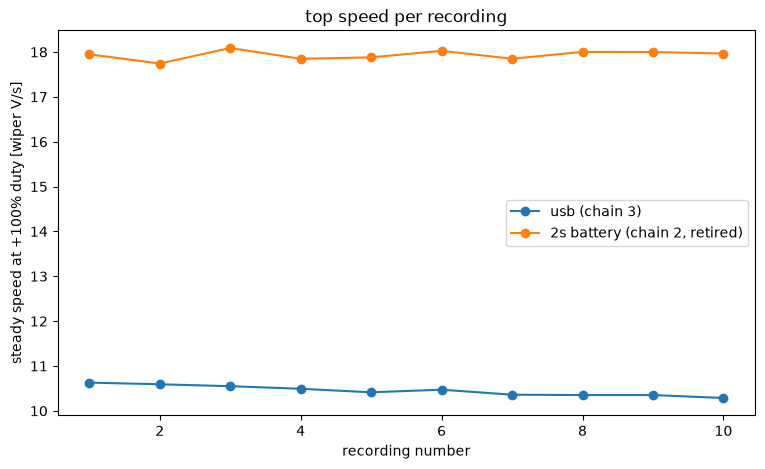

,mean_Vps,spread_pct
series,,
usb,10.450,3.279
2s battery,17.935,1.932


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
rows = []
for label, recs, ch in SERIES:
    xs, ys = [], []
    for name, (df, meta) in recs.items():
        n = int(name.split("-")[1])
        sp = step_speeds(df, ch)
        row = sp[np.isclose(sp["duty_pct"], 100.0, atol=0.1)]
        xs.append(n)
        ys.append(row["speed_Vps"].iloc[0])
    ax.plot(xs, ys, "-o", color=COLORS[label], label=f"{label} ({ch.label})")
    rows.append({"series": label,
                 "mean_Vps": np.mean(ys),
                 "spread_pct": (max(ys) - min(ys)) / np.mean(ys) * 100})
ax.set_xlabel("recording number")
ax.set_ylabel("steady speed at +100% duty [wiper V/s]")
ax.set_title("top speed per recording")
ax.legend()
plt.show()
pd.DataFrame(rows).set_index("series").round(3)


The ten recordings of each series agree within 3.3% (USB) and 1.9%
(battery) at full duty. The USB series drifts slowly downward over the
session, from 10.6 to 10.3 V/s, while its full-duty rail moved only from
4.44 to 4.43 V over the same ten recordings, so the rail does not explain
it. Plausible contributors include thermal changes in the gear train and
the motor. On the battery series the scatter has no trend, and the slow
discharge of the pack is a possible contributor there. Neither is
isolated or tested here. Any single recording carries a few percent of
unexplained variation, so fits in later notebooks pool across
recordings.

## 7. Limitations and open issues

- **One unit.** All numbers describe this one servo and this one board.
  The gear train has prior wear.
- **The board is a hacked rig.** Section 1 describes it. The bus
  telemetry stream couples into the current amplifier output on this
  board. It is flat within about a count at rest on this firmware build
  (section 5.2), but it is a limitation of the board, and I leave it as
  one. The next board revision does not have it, and nothing in this
  notebook is written to dodge it.
- **The two series are on different chains.** The battery series is on
  the retired chain 2 and is only here as a comparison until I recapture
  it. Anything that compares a voltage or a current between the two series
  is comparing chains as well as supplies.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal bias
  is measured per recording and per terminal, but the divider ratio it
  enters with is a design value.
- **The two terminals do not read the same bias at rest on chain 3.**
  Section 5.3 measures the split. Using each terminal's own rest reading
  absorbs it as an offset, and that is the whole treatment here. Whether
  it is a real potential difference or an ADC artifact is open.
- **Position linearity is not established.** The pot's voltage-vs-angle
  linearity is not measured here. Nothing in this notebook depends on it.
  Fits that combine distant regions of travel will have to address it.
- **80 ms drive steps are short.** High-duty steps reach steady speed well
  inside the window. The slowest moving steps are still accelerating when
  the window ends, so their fitted speeds read slightly low.
- **The sampling floors are this board's.** The 13.3% current floor and
  the 10.0% (chain 3) or 17.5% (chain 2) voltage floor change with the
  board revision.
- **Supply sense and NTC are not in this dataset.** The six-field wire
  budget left `vbus_raw` and `ntc_raw` out, so the supply is inferred from
  the driven terminal (section 6.2) and temperature is unobserved.
- **The two series are different sessions.** The current offset differs
  between them (section 5.2), so nothing here pools baseline constants
  across supplies.
- **Battery series exceeds the servo's usual rating.** The full-duty
  battery steps apply about 7.4 V to a mechanism usually rated 4.8 to 6 V.

## 8. Next notebooks

The same measurement chain supports the next derivations, each one
checked against the firmware's on-servo computation:

- Notebook 01 establishes what each of the four bridge states does to the
  terminals, the shunt and the motion, and gates every later sample on
  the bridge state.
- Notebook 03 derives the back-EMF constant, notebook 04 the friction,
  including the motion threshold measured here, and notebook 05 the
  inertia.
- The firmware's supply estimator and current-offset handling, re-derived
  from this raw data and compared against the servo's live values.
- A battery recapture on chain 3, so the two-supply comparison in section
  6.3 stops mixing chains.
